# Modelo y análsis

### Pquetes

In [153]:
# ---------- 0) Paquetes ----------
pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "statsmodels", "scipy"]

import subprocess, sys
for p in pkgs:
    try: __import__(p)
    except: subprocess.run([sys.executable, "-m", "pip", "install", p], capture_output=True)

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm, statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("\n[OK] Paquetes listos.")


[OK] Paquetes listos.


### Preparar y cargar datos

In [157]:
df = pd.read_excel('/content/Data.xlsx')
df.to_csv('data.csv', index=False)            #Por costumbre lo trabajé en csv
print("Excel convertido a CSV exitosamente")
print("=" *60)

# Reemplazar comas por puntos y asegurar numéricos
df = df.apply(lambda x: x.astype(str).str.replace(',', '.'))
df = df.apply(pd.to_numeric, errors='coerce')
print(df.dtypes)

print("=" *60)
print("\n[OK] Datos listos.")

df.head()

Excel convertido a CSV exitosamente
Individuo      int64
lnsalario    float64
educ           int64
edad           int64
edad2          int64
urban          int64
soltero        int64
casado         int64
femenino       int64
dtype: object

[OK] Datos listos.


,Individuo,lnsalario,educ,edad,edad2,urban,soltero,casado,femenino
0,1,0.884654,10,25,625,0,1,0,0
1,2,0.519194,5,44,1936,1,0,1,0
2,3,0.835863,10,40,1600,1,0,1,0
3,4,1.415282,10,40,1600,1,0,1,0
4,5,1.905488,12,23,529,0,0,1,1


### Resumen de estadísticos

In [152]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Resumen de principales estadísticos
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
print("Resumen estadístico de las variables:")
print(df[['lnsalario', 'educ', 'edad', 'edad2', 'urban', 'casado', 'femenino']].describe())

Resumen estadístico de las variables:
         lnsalario         educ         edad        edad2        urban  \
count  7004.000000  7004.000000  7004.000000  7004.000000  7004.000000   
mean      2.841967     9.399343    33.501428  1239.051114     0.619075   
std       0.740214     4.156101    10.803801   772.394310     0.485649   
min      -1.486140     5.000000    14.000000   196.000000     0.000000   
25%       2.416314     5.000000    25.000000   625.000000     0.000000   
50%       2.844534     9.000000    33.000000  1089.000000     1.000000   
75%       3.247863    12.000000    41.000000  1681.000000     1.000000   
max       7.945743    16.000000    60.000000  3600.000000     1.000000   

            casado     femenino  
count  7004.000000  7004.000000  
mean      0.696887     0.105654  
std       0.459636     0.307416  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       1.000000     0.000000  
75%       1.000000     0.000000  
max       1.000000     

### Gráficos

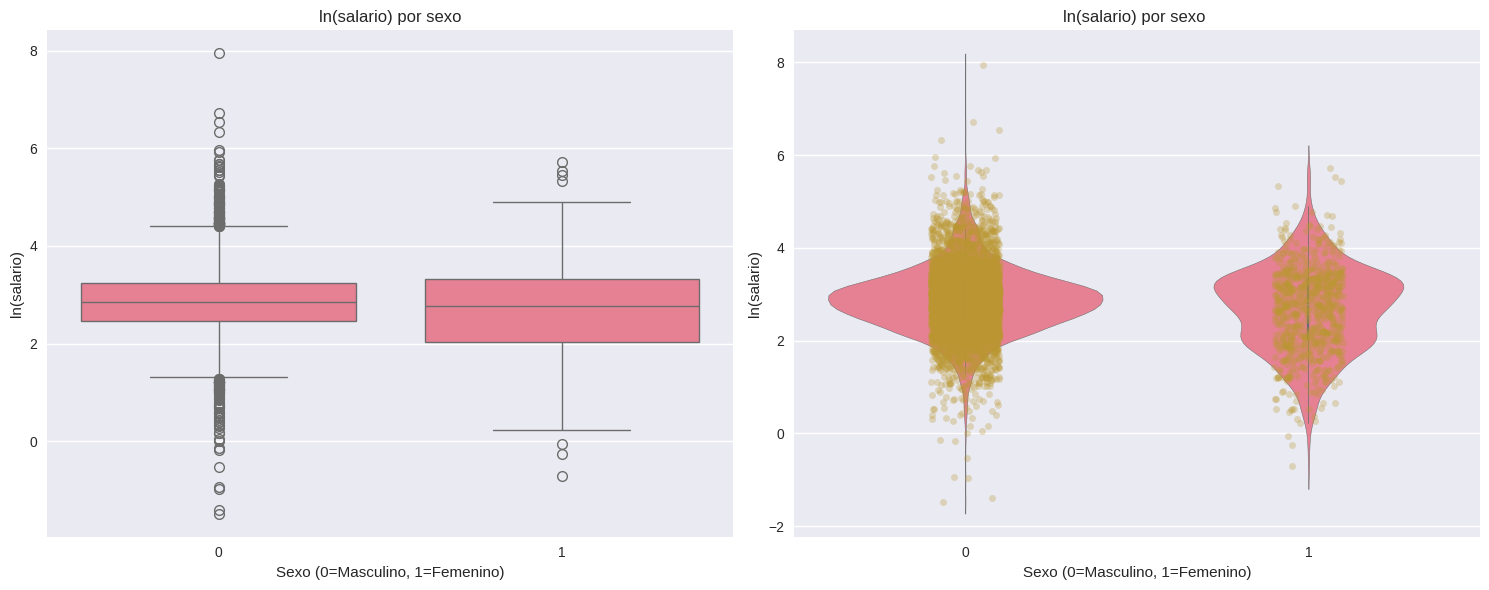

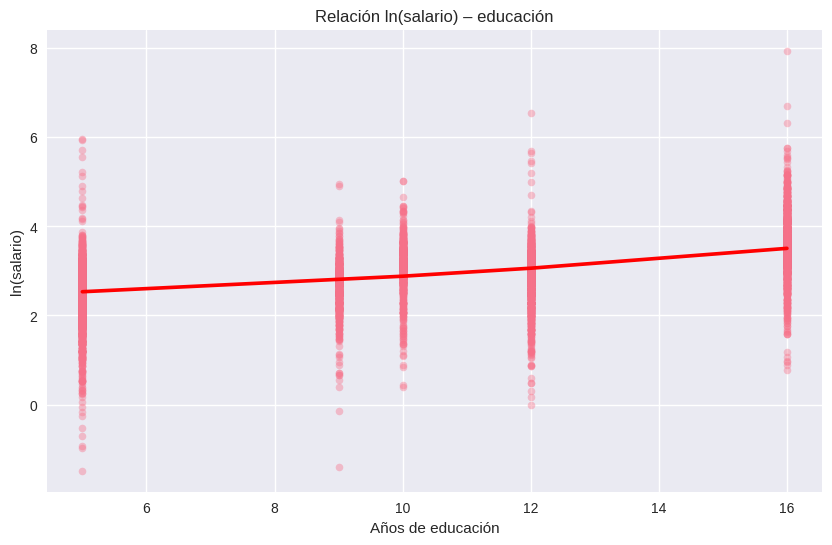

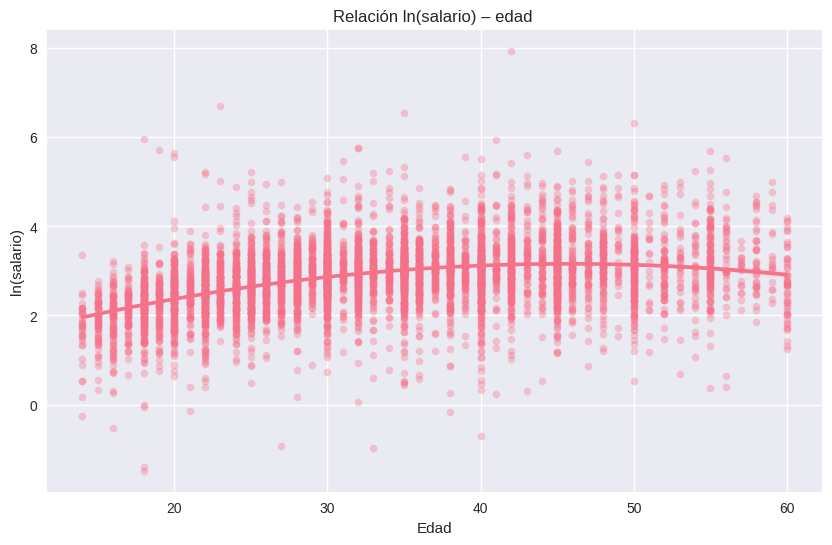

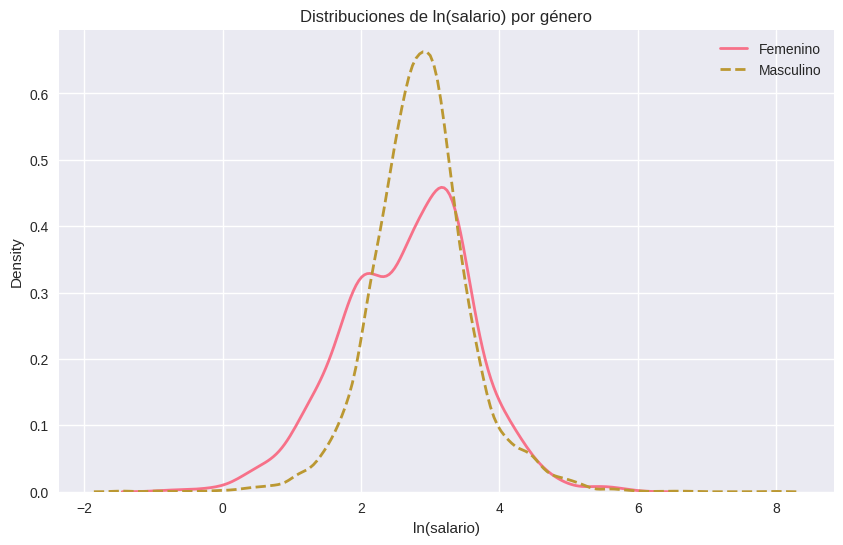

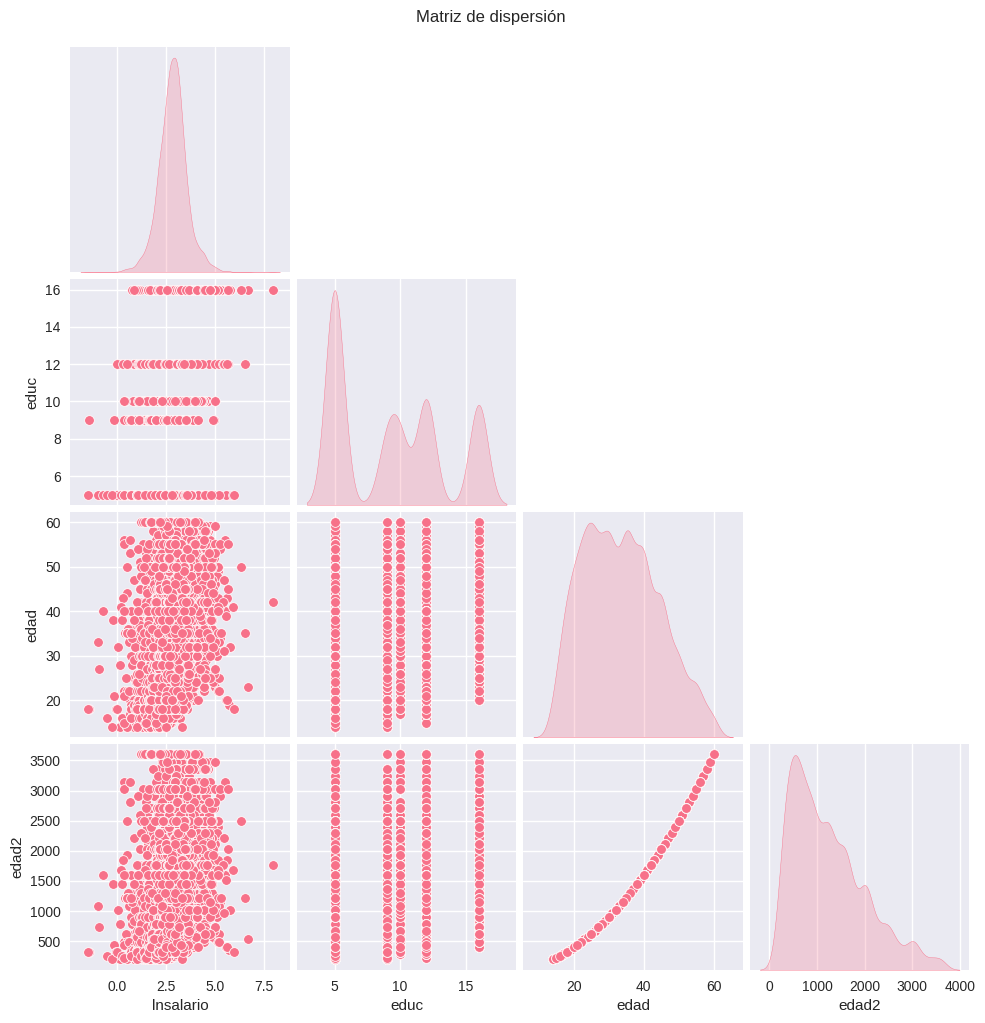

In [161]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Revisión de gráfico
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Boxplot/violin-like por sexo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot
sns.boxplot(x='femenino', y='lnsalario', data=df, ax=ax1)
ax1.set_title('ln(salario) por sexo')
ax1.set_ylabel('ln(salario)')
ax1.set_xlabel('Sexo (0=Masculino, 1=Femenino)')

# Violin plot
sns.violinplot(x='femenino', y='lnsalario', data=df, ax=ax2)
sns.stripplot(x='femenino', y='lnsalario', data=df, alpha=0.3, jitter=True, ax=ax2)
ax2.set_title('ln(salario) por sexo ')
ax2.set_ylabel('ln(salario)')
ax2.set_xlabel('Sexo (0=Masculino, 1=Femenino)')

plt.tight_layout()
plt.show()

# lnsalari - escol
plt.figure(figsize=(10, 6))
sns.regplot(x='educ', y='lnsalario', data=df,
            scatter_kws={'alpha':0.4, 's':30},
            lowess=True,
            line_kws={'color':'red'})
plt.title('Relación ln(salario) – educación')
plt.xlabel('Años de educación')
plt.ylabel('ln(salario)')
plt.show()

# lnsalario - edad
plt.figure(figsize=(10, 6))
sns.regplot(x='edad', y='lnsalario', data=df,
            scatter_kws={'alpha':0.35, 's':30},
            order=2,
            ci=95)
plt.title('Relación ln(salario) – edad ')
plt.xlabel('Edad')
plt.ylabel('ln(salario)')
plt.show()

# Densidades  por género
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['femenino'] == 1], x='lnsalario', label='Femenino', linewidth=2)
sns.kdeplot(data=df[df['femenino'] == 0], x='lnsalario', label='Masculino', linestyle='--', linewidth=2)
plt.title('Distribuciones de ln(salario) por género')
plt.xlabel('ln(salario)')
plt.legend()
plt.show()

# Matriz de dispersión
variables = ['lnsalario', 'educ', 'edad', 'edad2']
sns.pairplot(df[variables], diag_kind='kde', corner=True)
plt.suptitle('Matriz de dispersión ', y=1.02)
plt.show()

### Regresiones

In [112]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Análisis de Regresiones
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Modelos
model1 = smf.ols('lnsalario ~ educ', data=df).fit()
model2 = smf.ols('lnsalario ~ educ + edad + edad2 + urban', data=df).fit()
model3 = smf.ols('lnsalario ~ educ + edad + edad2 + urban + casado + femenino', data=df).fit()

# Para interacción
df['educxfemenino'] = df['educ'] * df['femenino']
model4 = smf.ols('lnsalario ~ educ + edad + edad2 + urban + casado + femenino + educxfemenino', data=df).fit()

# Mostrar resultados
print("=== MODELO 1 ===")
print(model1.summary())
print("\n=== MODELO 2 ===")
print(model2.summary())
print("\n=== MODELO 3 ===")
print(model3.summary())
print("\n=== MODELO 4 ===")
print(model4.summary())

# AIC y BIC
models = [model1, model2, model3, model4]
model_names = ['Model1', 'Model2', 'Model3', 'Model4']

aic_bic = pd.DataFrame({
    'Modelo': model_names,
    'AIC': [model.aic for model in models],
    'BIC': [model.bic for model in models],
    'R2_ajustado': [model.rsquared_adj for model in models]
})
print("\n=== COMPARACIÓN DE MODELOS (AIC/BIC) ===")
print(aic_bic)

=== MODELO 1 ===
                            OLS Regression Results                            
Dep. Variable:              lnsalario   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     2425.
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        01:53:09   Log-Likelihood:                -6789.2
No. Observations:                7004   AIC:                         1.358e+04
Df Residuals:                    7002   BIC:                         1.360e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9929      0.019   

### Hipótesis


=== PRUEBA PARA femenino ===
Coeficiente femenino: -0.2554
Valor-t: -11.2934
P-valor: 0.0000

=== INTERACCIONES CONJUNTAS ===
Estadístico F: 15.2263
P-valor: 0.0000
Grados de libertad: 5.0, 6992.0

=== EDAD ÓPTIMA ===
Edad que maximiza salario: 50.83
Diferencia con 50: 0.83


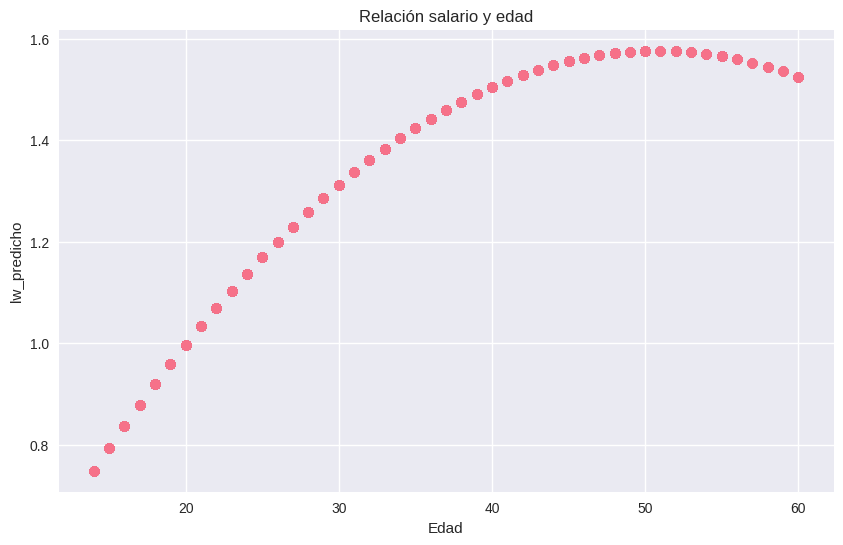


=== Comparacón de modelos (AIC/BIC) ===
   Modelo           AIC           BIC  R2_ajustado
0  Model1  13582.494094  13596.202568     0.257166
1  Model2  12272.493691  12306.764875     0.384147
2  Model3  12112.828233  12160.807890     0.398199
3  Model4  12048.677910  12103.511804     0.403771


In [163]:

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Pruebas de hipótesis
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Para ipótesis individual
print("\n=== PRUEBA PARA femenino ===")
print(f"Coeficiente femenino: {model3.params['femenino']:.4f}")
print(f"Valor-t: {model3.tvalues['femenino']:.4f}")
print(f"P-valor: {model3.pvalues['femenino']:.4f}")

# Test conjunta
hypothesis_inter = 'i1 = 0, i2 = 0, i3 = 0, i4 = 0, i5 = 0'
f_test_inter = model_interacciones.f_test(hypothesis_inter)
print(f"\n=== INTERACCIONES CONJUNTAS ===")
print(f"Estadístico F: {f_test_inter.fvalue:.4f}")  # Cambio aquí
print(f"P-valor: {f_test_inter.pvalue:.4f}")
print(f"Grados de libertad: {f_test_inter.df_num}, {f_test_inter.df_denom}")

# Óptimo de edad
edad_coef = model3.params['edad']
edad2_coef = model3.params['edad2']
edad_optima = -edad_coef / (2 * edad2_coef)
diferencia = edad_optima - 50

print(f"\n=== EDAD ÓPTIMA ===")
print(f"Edad que maximiza salario: {edad_optima:.2f}")
print(f"Diferencia con 50: {diferencia:.2f}")

# Predicción gráfico
df['lw_predicho'] = model3.params['edad'] * df['edad'] + model3.params['edad2'] * df['edad2']
plt.figure(figsize=(10, 6))
plt.scatter(df['edad'], df['lw_predicho'], alpha=0.6)
plt.xlabel('Edad')
plt.ylabel('lw_predicho')
plt.title('Relación salario y edad')
plt.show()

# AIC y BIC
models = [model1, model2, model3, model4]
model_names = ['Model1', 'Model2', 'Model3', 'Model4']

aic_bic = pd.DataFrame({
    'Modelo': model_names,
    'AIC': [model.aic for model in models],
    'BIC': [model.bic for model in models],
    'R2_ajustado': [model.rsquared_adj for model in models]
})
print("\n=== Comparacón de modelos (AIC/BIC) ===")
print(aic_bic)


### Diagnóstico del modelo


=== TEST RESET DE RAMSEY ===
Estadístico F: 67.6198
P-valor: 0.0000

=== FACTORES DE INFLACIÓN DE VARIANZA (VIF) ===
   Variable         VIF
0     const  112.657785
1      educ    1.090961
2      edad   53.704607
3     edad2   47.588855
4     urban    1.056421
5    casado    2.052867
6  femenino    1.026805

=== MATRIZ DE CORRELACIONES ===
              educ      edad     edad2     urban    casado  femenino
educ      1.000000  0.079700  0.050681  0.188997  0.045359  0.105895
edad      0.079700  1.000000  0.986047  0.041172  0.602535 -0.059765
edad2     0.050681  0.986047  1.000000  0.043828  0.532868 -0.057713
urban     0.188997  0.041172  0.043828  1.000000 -0.074656  0.068755
casado    0.045359  0.602535  0.532868 -0.074656  1.000000 -0.108837
femenino  0.105895 -0.059765 -0.057713  0.068755 -0.108837  1.000000

=== MODELO CON VARIABLES CENTRADAS ===
                            OLS Regression Results                            
Dep. Variable:              lnsalario   R-squared:     

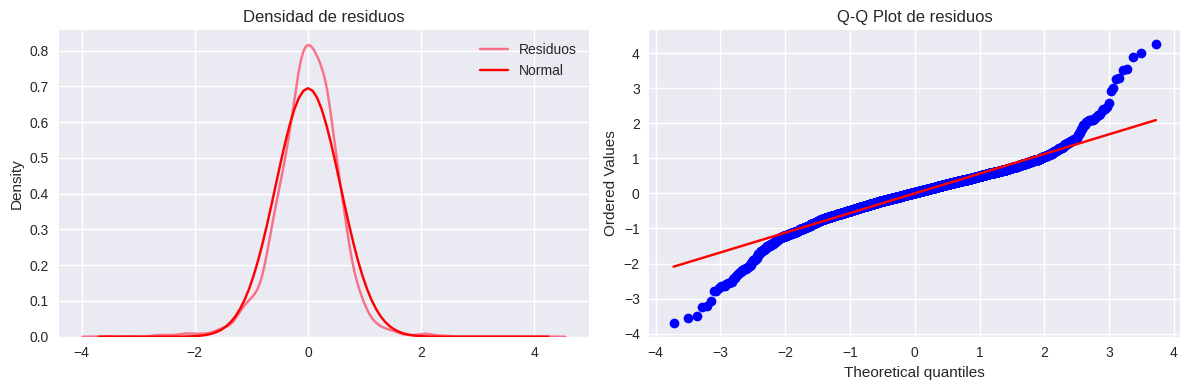


=== TEST DE NORMALIDAD  ===
Estadístico: 5937.0102
P-valor: 0.0000

=== TEST DE HETEROCEDASTICIDAD (BREUSCH-PAGAN) ===
Estadístico LM: 57.4341
P-valor: 0.0000

=== Model con errores robustos ===
                            OLS Regression Results                            
Dep. Variable:              lnsalario   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     667.2
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        04:03:36   Log-Likelihood:                -6049.4
No. Observations:                7004   AIC:                         1.211e+04
Df Residuals:                    6997   BIC:                         1.216e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
              

In [164]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Diagnóstico del modelo
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Ramsey
def ramsey_reset_test(model, power=3):
    """Test RESET de Ramsey"""
    y = model.model.endog
    X = model.model.exog
    y_pred = model.predict()

    # Añadir potencias de los valores predichos
    X_reset = np.column_stack([X] + [y_pred**i for i in range(2, power+1)])

    # Regresión auxiliar
    reset_model = sm.OLS(y, X_reset).fit()

    # Test F
    k = X.shape[1]
    rss_original = model.ssr
    rss_reset = reset_model.ssr
    f_stat = ((rss_original - rss_reset) / (power - 1)) / (rss_reset / (len(y) - X_reset.shape[1]))
    p_value = 1 - stats.f.cdf(f_stat, power - 1, len(y) - X_reset.shape[1])

    return f_stat, p_value

f_reset, p_reset = ramsey_reset_test(model3)
print(f"\n=== TEST RESET DE RAMSEY ===")
print(f"Estadístico F: {f_reset:.4f}")
print(f"P-valor: {p_reset:.4f}")

# VIF para multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    """Calcula VIF para cada variable"""
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

X_vif = df[['educ', 'edad', 'edad2', 'urban', 'casado', 'femenino']]
X_vif = sm.add_constant(X_vif)
vif_results = calculate_vif(X_vif)
print("\n=== FACTORES DE INFLACIÓN DE VARIANZA (VIF) ===")
print(vif_results)

# Matriz de correlaciones
corr_matrix = df[['educ', 'edad', 'edad2', 'urban', 'casado', 'femenino']].corr()
print("\n=== MATRIZ DE CORRELACIONES ===")
print(corr_matrix)

# Para reducir multicolinealidad
edad_mean = df['edad'].mean()
df['edad_c'] = df['edad'] - edad_mean
df['edad2_c'] = df['edad_c']**2

model_centrado = smf.ols('lnsalario ~ educ + edad_c + edad2_c + urban + casado + femenino', data=df).fit()
print("\n=== MODELO CON VARIABLES CENTRADAS ===")
print(model_centrado.summary())

# Normalidad y heterocedasticidad
residuos = model3.resid

# Gráfico densidad de residuos
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(residuos, label='Residuos')
x = np.linspace(residuos.min(), residuos.max(), 100)
plt.plot(x, stats.norm.pdf(x, residuos.mean(), residuos.std()), 'r-', label='Normal')
plt.title('Densidad de residuos')
plt.legend()

plt.subplot(1, 2, 2)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Q-Q Plot de residuos')

plt.tight_layout()
plt.show()

# Test de normalidad
jb_stat, jb_pvalue = stats.jarque_bera(residuos)
print(f"\n=== TEST DE NORMALIDAD  ===")
print(f"Estadístico: {jb_stat:.4f}")
print(f"P-valor: {jb_pvalue:.4f}")

# Test de heterocedasticidad (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuos, model3.model.exog)
print(f"\n=== TEST DE HETEROCEDASTICIDAD (BREUSCH-PAGAN) ===")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"P-valor: {bp_test[1]:.4f}")

# Corrección con errores robustos
model3_robust = smf.ols('lnsalario ~ educ + edad + edad2 + urban + casado + femenino', data=df).fit(cov_type='HC3')
print("\n=== Model con errores robustos ===")
print(model3_robust.summary())


### Test de Chow y vI

In [165]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Test de Chow y variables de interacción
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Crear variables de interacción para estabilidad
for i, var in enumerate(['educ', 'edad', 'edad2', 'urban', 'casado'], 1):
    df[f'i{i}'] = df['femenino'] * df[var]

# Modelo completo
model_interacciones = smf.ols('lnsalario ~ educ + edad + edad2 + urban + casado + femenino + i1 + i2 + i3 + i4 + i5', data=df).fit()
print("\n=== Modelo completo ===")
print(model_interacciones.summary())

# Test conjunta de  interacciones
hypothesis_inter = 'i1 = 0, i2 = 0, i3 = 0, i4 = 0, i5 = 0'
f_test_inter = model_interacciones.f_test(hypothesis_inter)

hypothesis_inter = 'i1 = 0, i2 = 0, i3 = 0, i4 = 0, i5 = 0'
f_test_inter = model_interacciones.f_test(hypothesis_inter)

print(f"\n=== Test conjunto ===")
print(f"Estadístico F: {f_test_inter.fvalue:.4f}")
print(f"P-valor: {f_test_inter.pvalue:.4f}")
print(f"Grados de libertad: {f_test_inter.df_num}, {f_test_inter.df_denom}")


=== Modelo completo ===
                            OLS Regression Results                            
Dep. Variable:              lnsalario   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     433.0
Date:                Thu, 13 Nov 2025   Prob (F-statistic):               0.00
Time:                        04:06:46   Log-Likelihood:                -6011.5
No. Observations:                7004   AIC:                         1.205e+04
Df Residuals:                    6992   BIC:                         1.213e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6875      

### Cuantílicas


=== REGRESIÓN CUANTÍLICA (Q10) ===
                         QuantReg Regression Results                          
Dep. Variable:              lnsalario   Pseudo R-squared:               0.2096
Model:                       QuantReg   Bandwidth:                      0.1043
Method:                 Least Squares   Sparsity:                        3.060
Date:                Thu, 13 Nov 2025   No. Observations:                 7004
Time:                        04:07:56   Df Residuals:                     6997
                                        Df Model:                            6
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3148      0.122     -2.578      0.010      -0.554      -0.075
educ           0.0772      0.003     28.159      0.000       0.072       0.083
edad           0.0835      0.008     10.635      0.000       0.068       0.099
edad2         -0

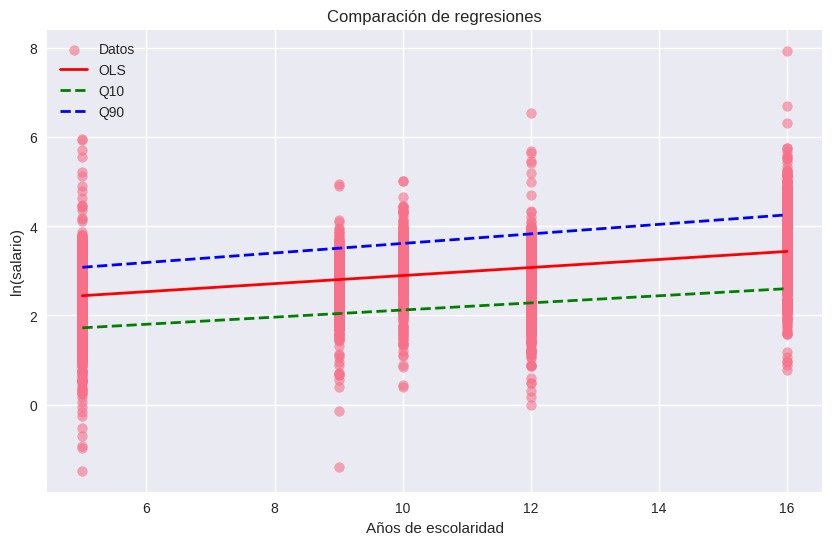

In [166]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Regresiones cuantílicas
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from statsmodels.regression.quantile_regression import QuantReg

# Regresiones cuantílicas
qreg_10 = QuantReg(df['lnsalario'], sm.add_constant(df[['educ', 'edad', 'edad2', 'urban', 'casado', 'femenino']])).fit(q=0.1)
qreg_50 = QuantReg(df['lnsalario'], sm.add_constant(df[['educ', 'edad', 'edad2', 'urban', 'casado', 'femenino']])).fit(q=0.5)
qreg_90 = QuantReg(df['lnsalario'], sm.add_constant(df[['educ', 'edad', 'edad2', 'urban', 'casado', 'femenino']])).fit(q=0.9)

print("\n=== REGRESIÓN CUANTÍLICA (Q10) ===")
print(qreg_10.summary())
print("\n=== REGRESIÓN CUANTÍLICA (Q50 - Mediana) ===")
print(qreg_50.summary())
print("\n=== REGRESIÓN CUANTÍLICA (Q90) ===")
print(qreg_90.summary())

# Comparación dde los modelos
comparison_qreg = pd.DataFrame({
    'Cuantil': ['Q10', 'Q50', 'Q90'],
    'Intercepto': [qreg_10.params[0], qreg_50.params[0], qreg_90.params[0]],
    'educ': [qreg_10.params[1], qreg_50.params[1], qreg_90.params[1]],
    'femenino': [qreg_10.params[6], qreg_50.params[6], qreg_90.params[6]]
})
print("\n=== COMPARACIÓN REGRESIONES CUANTÍLICAS ===")
print(comparison_qreg)

# Gráfico de cuantílicas
plt.figure(figsize=(10, 6))
plt.scatter(df['educ'], df['lnsalario'], alpha=0.6, label='Datos')

# Ajustar modelos simples para gráfico
q10_simple = QuantReg(df['lnsalario'], sm.add_constant(df['educ'])).fit(q=0.1)
q90_simple = QuantReg(df['lnsalario'], sm.add_constant(df['educ'])).fit(q=0.9)
ols_simple = smf.ols('lnsalario ~ educ', data=df).fit()

x_vals = np.linspace(df['educ'].min(), df['educ'].max(), 100)
plt.plot(x_vals, ols_simple.params[0] + ols_simple.params[1] * x_vals,
         'r-', label='OLS', linewidth=2)
plt.plot(x_vals, q10_simple.params[0] + q10_simple.params[1] * x_vals,
         'g--', label='Q10', linewidth=2)
plt.plot(x_vals, q90_simple.params[0] + q90_simple.params[1] * x_vals,
         'b--', label='Q90', linewidth=2)

plt.xlabel('Años de escolaridad')
plt.ylabel('ln(salario)')
plt.title('Comparación de regresiones')
plt.legend()
plt.show()

## Exportar

In [167]:
# Exportar resultados de modelos
results_dict = {
    'Model1': model1.params,
    'Model2': model2.params,
    'Model3': model3.params,
    'Model4': model4.params
}

results_df = pd.DataFrame(results_dict)
results_df.to_excel('Resultado_aprox-outreg2-.xlsx')